# Charts and exports

A linkage produces four kinds of visual output, and they are for four different
audiences. This notebook produces each one, says what it is for, and — the part
usually left out — says when it misleads.

**What you will do**

1. Produce the four diagnostic charts a linkage model generates
2. Read each one, including its failure modes
3. Build the two charts a non-technical audience actually needs
4. Export the dashboards and files that make up a linkage deliverable

## 0. Setup

In [1]:
import unicodedata
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

DATA = Path("../../data")
if not DATA.exists():
    DATA = Path("data")

fonasa = pd.read_csv(DATA / "fonasa_sample.csv", dtype=str)
suseso = pd.read_csv(DATA / "suseso_sample.csv", dtype=str)


def basic_text_clean(series):
    return (series.astype("string").str.strip().str.upper()
            .str.replace(r"\s+", " ", regex=True))


def remove_accents(value):
    if pd.isna(value):
        return pd.NA
    value = unicodedata.normalize("NFKD", str(value))
    return "".join(c for c in value if not unicodedata.combining(c))


def standardise_name(series):
    cleaned = basic_text_clean(series)
    cleaned = cleaned.map(remove_accents, na_action="ignore").astype("string")
    cleaned = cleaned.str.replace(r"[^A-ZN ]", "", regex=True)
    return cleaned.str.replace(r"\s+", " ", regex=True).str.strip()


def clean_sex(series):
    cleaned = basic_text_clean(series)
    return cleaned.replace({"HOMBRE": "M", "MUJER": "F", "MASCULINO": "M",
                            "FEMENINO": "F", "": pd.NA})


for df in (fonasa, suseso):
    for col in ["nombre", "ap1", "ap2"]:
        df[f"{col}_clean"] = standardise_name(df[col])
    df["sexo_clean"] = clean_sex(df["sexo"])
    df["nac_clean"] = basic_text_clean(df["nacionalidad"])

CLEAN = ["nombre_clean", "ap1_clean", "ap2_clean", "sexo_clean", "nac_clean"]
TRUE_MATCHES = 4500

print(f"fonasa: {len(fonasa):,} records | suseso: {len(suseso):,} records")
print(f"true matches present in the data: {TRUE_MATCHES:,}")


import phonetics


def dmeta_primary(value):
    """Primary Double Metaphone code, as a string. Used for blocking."""
    if pd.isna(value) or value == "":
        return None
    try:
        return phonetics.dmetaphone(str(value))[0] or None
    except Exception:
        return None


def dmeta_list(value):
    """Both Double Metaphone codes, as a list. This is the form Splink's
    comparison functions expect for a `dmeta_col_name` argument."""
    if pd.isna(value) or value == "":
        return None
    try:
        return [c for c in phonetics.dmetaphone(str(value)) if c] or None
    except Exception:
        return None


for df in (fonasa, suseso):
    for col in ["nombre_clean", "ap1_clean", "ap2_clean"]:
        stem = col.replace("_clean", "")
        df[f"{stem}_dm"] = df[col].map(dmeta_primary)      # string, for blocking
        df[f"{stem}_dmeta"] = df[col].map(dmeta_list)      # list, for comparisons

MODEL_COLS = (["unique_id"] + CLEAN
              + ["nombre_dm", "ap1_dm", "ap2_dm"]
              + ["nombre_dmeta", "ap1_dmeta", "ap2_dmeta"])
fonasa_m = fonasa[MODEL_COLS + ["true_person_id"]].copy()
suseso_m = suseso[MODEL_COLS + ["true_person_id"]].copy()

print("phonetic example:  GONZALEZ ->",
      dmeta_primary("GONZALEZ"), "(blocking) /", dmeta_list("GONZALEZ"), "(comparison)")

fonasa: 30,000 records | suseso: 27,000 records
true matches present in the data: 4,500
phonetic example:  GONZALEZ -> KNSLS (blocking) / ['KNSLS'] (comparison)


In [2]:
from pathlib import Path
from splink import DuckDBAPI, Linker
import vl_convert as vlc
from IPython.display import Image


def show(chart, scale=2):
    return Image(vlc.vegalite_to_png(chart.to_json(), scale=scale))


MODEL_DIR = Path("../../models")
if not MODEL_DIR.exists():
    MODEL_DIR = Path("models")

linker = Linker(
    input_table_or_tables=[fonasa_m, suseso_m],
    settings=str(MODEL_DIR / "linkage-model.json"),
    db_api=DuckDBAPI(),
    input_table_aliases=["fonasa", "suseso"],
)
df_predict = linker.inference.predict()
predictions = df_predict.as_pandas_dataframe()
predictions["is_true_match"] = (
    predictions["true_person_id_l"] == predictions["true_person_id_r"]
)
THRESHOLD = 0.9
print(f"{len(predictions):,} candidate pairs scored")

Blocking time: 0.06 seconds
Predict time: 0.10 seconds


8,868 candidate pairs scored


```{note}
Splink returns interactive Altair charts. This book renders them to static images
so they survive publication; in your own session, display the chart object and
you can hover, zoom and inspect.
```

## 1. Model parameters — what the model believes

The match-weights chart is the model in one picture. Every comparison level, and
what agreement or disagreement at that level is worth in bits.

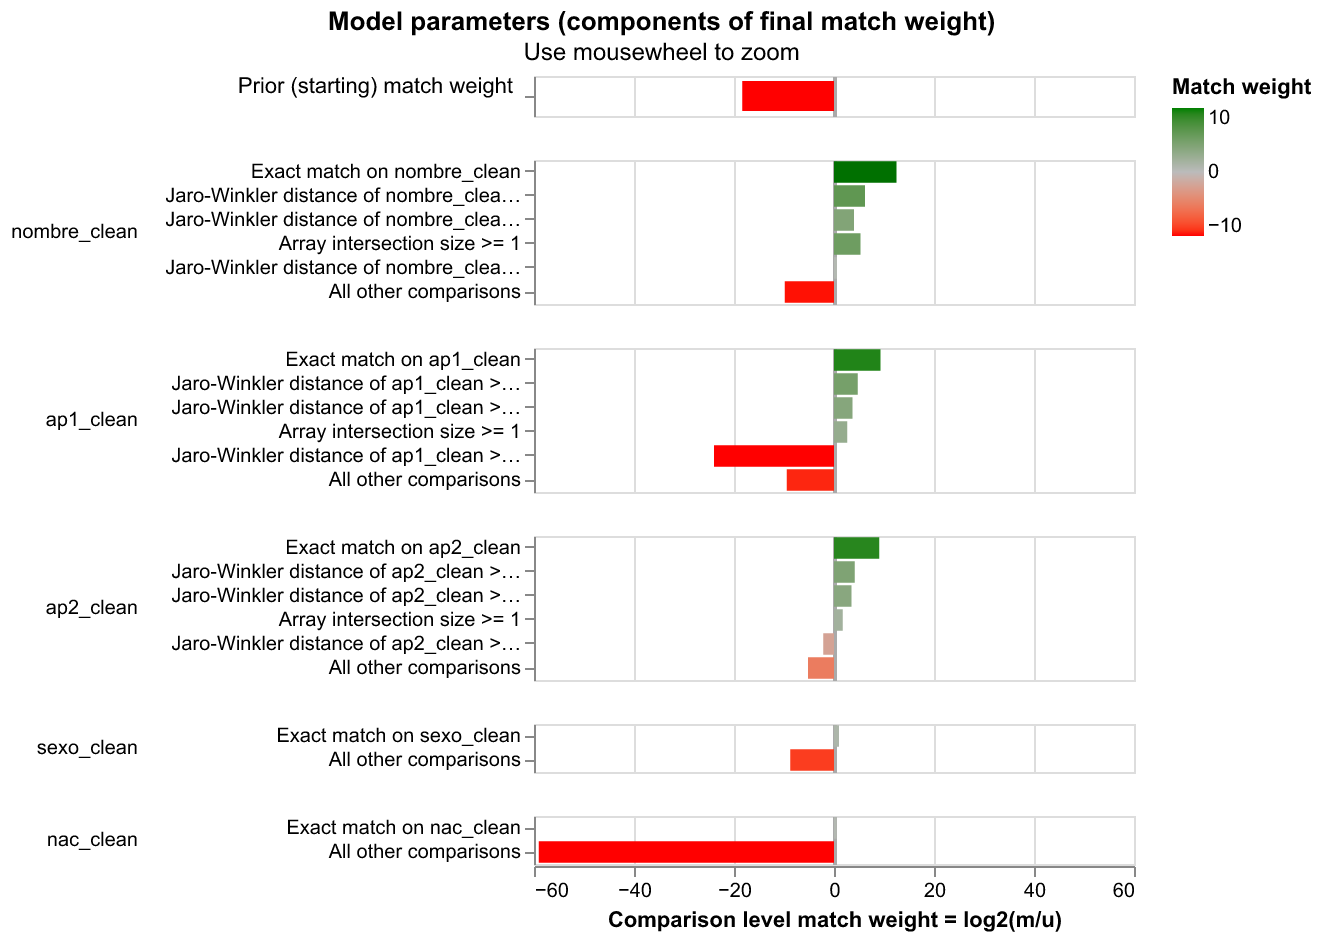

In [3]:
show(linker.visualisations.match_weights_chart())

**What it is for.** Sanity-checking the model before you trust its output, and
explaining to a technical reviewer what the model does.

**How to read it.** The bar at the top is the prior — the deficit every pair
starts with. Below it, each comparison contributes positively when it agrees and
negatively when it does not, with intermediate similarity levels in between.

**What to look for, and what it means when you see it:**

- *A level with a weight of zero or a suspiciously round number.* It was probably
  never trained, and is sitting at a default. Splink warns about this; the chart
  is where you notice you ignored the warning.
- *Non-monotonic levels* — a looser similarity level worth more than a stricter
  one. This is a genuine red flag: it usually means too little data reached that
  level for a stable estimate.
- *One field dominating everything.* Check that it is not a near-duplicate of
  another field, which would double-count the same evidence.

**When it misleads.** The weights are conditioned on the candidate set, as
chapter 2.6 showed. A tall bar means "strong evidence among the pairs blocking
let through", not "this field is accurate in our register".

## 2. m and u separately

The same parameters split into their two components, which is more useful than it
sounds: *m* and *u* answer different questions and fail in different ways.

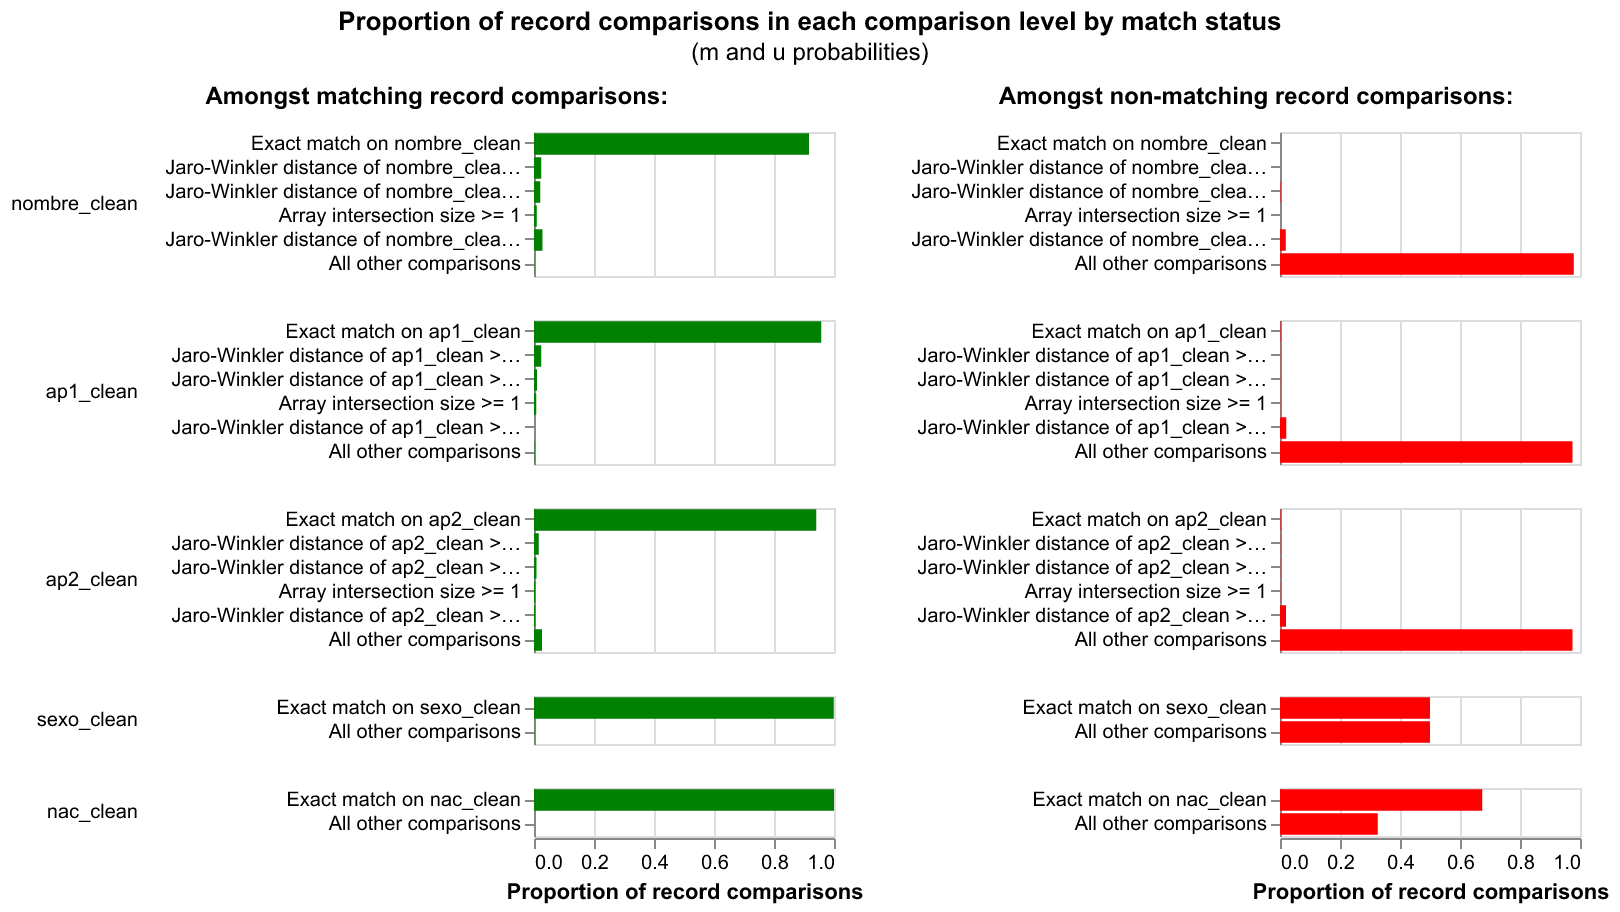

In [4]:
show(linker.visualisations.m_u_parameters_chart())

**What it is for.** Diagnosing *which* of the two estimates is the problem when a
weight looks wrong.

**How to read it.** The *u* panel should look like the frequency structure of your
data: a common value agrees often by chance, a rare one almost never. The *m*
panel should look like your data quality: how often genuine matches agree.

**What to look for.** A *u* estimate that does not match what you know about your
data's cardinality means the sampling went wrong. An *m* estimate near 1.0 for
every level means EM has converged to something degenerate, or the training
blocking rule was so strict that everything in it agreed.

## 3. The score distribution

The single most informative chart about whether the linkage worked at all.

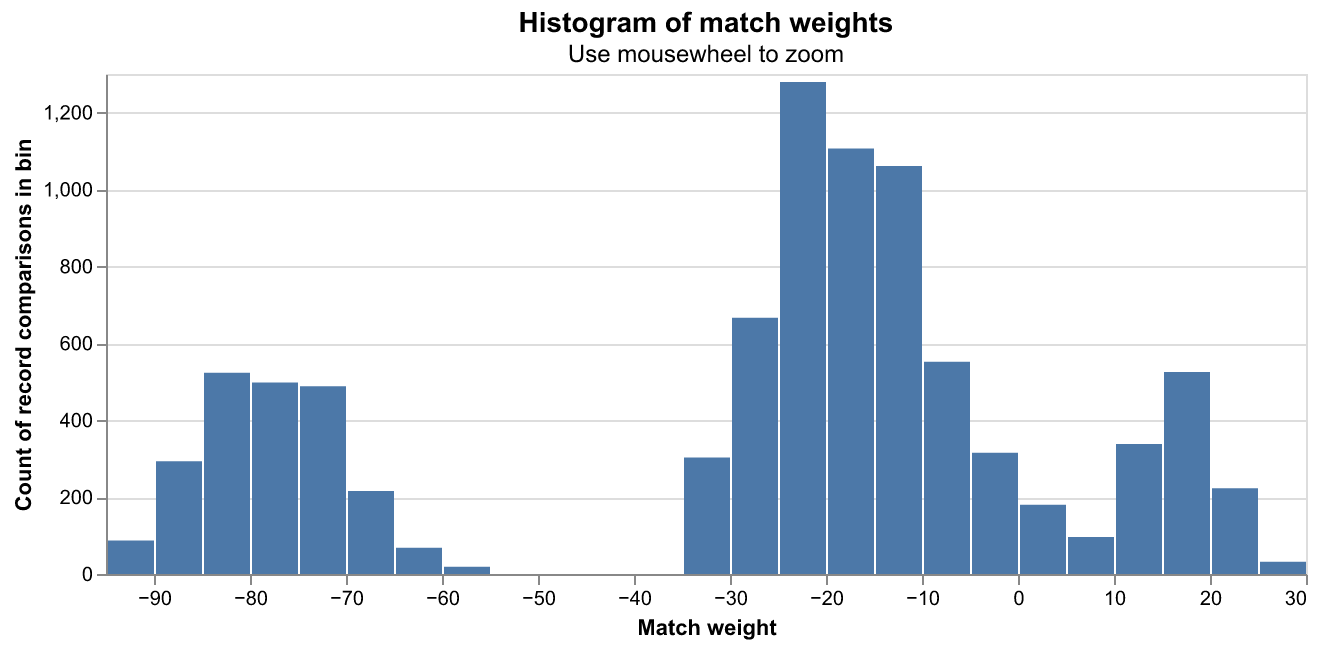

In [5]:
show(linker.visualisations.match_weights_histogram(df_predict))

**What it is for.** Deciding whether the model separates the two populations, and
where a threshold can sensibly go.

**How to read it.** You want two humps: pairs the model is confident about in
each direction, with a thin region between them. A threshold placed in the thin
region decides few pairs, so the decision is cheap.

**When it misleads.** A *single* smooth distribution is the warning. It means the
model cannot separate matches from non-matches, and no threshold will fix that —
the answer is better comparisons or better blocking, not a better cut-off.

Note also that this chart shows only the **candidate** pairs. It cannot show the
matches that blocking discarded, and those do not appear anywhere in it. A
beautiful bimodal histogram is entirely compatible with having lost 60% of the
true matches upstream.

## 4. Individual pairs — the waterfall

The other three charts are about the model. This one is about a single decision.

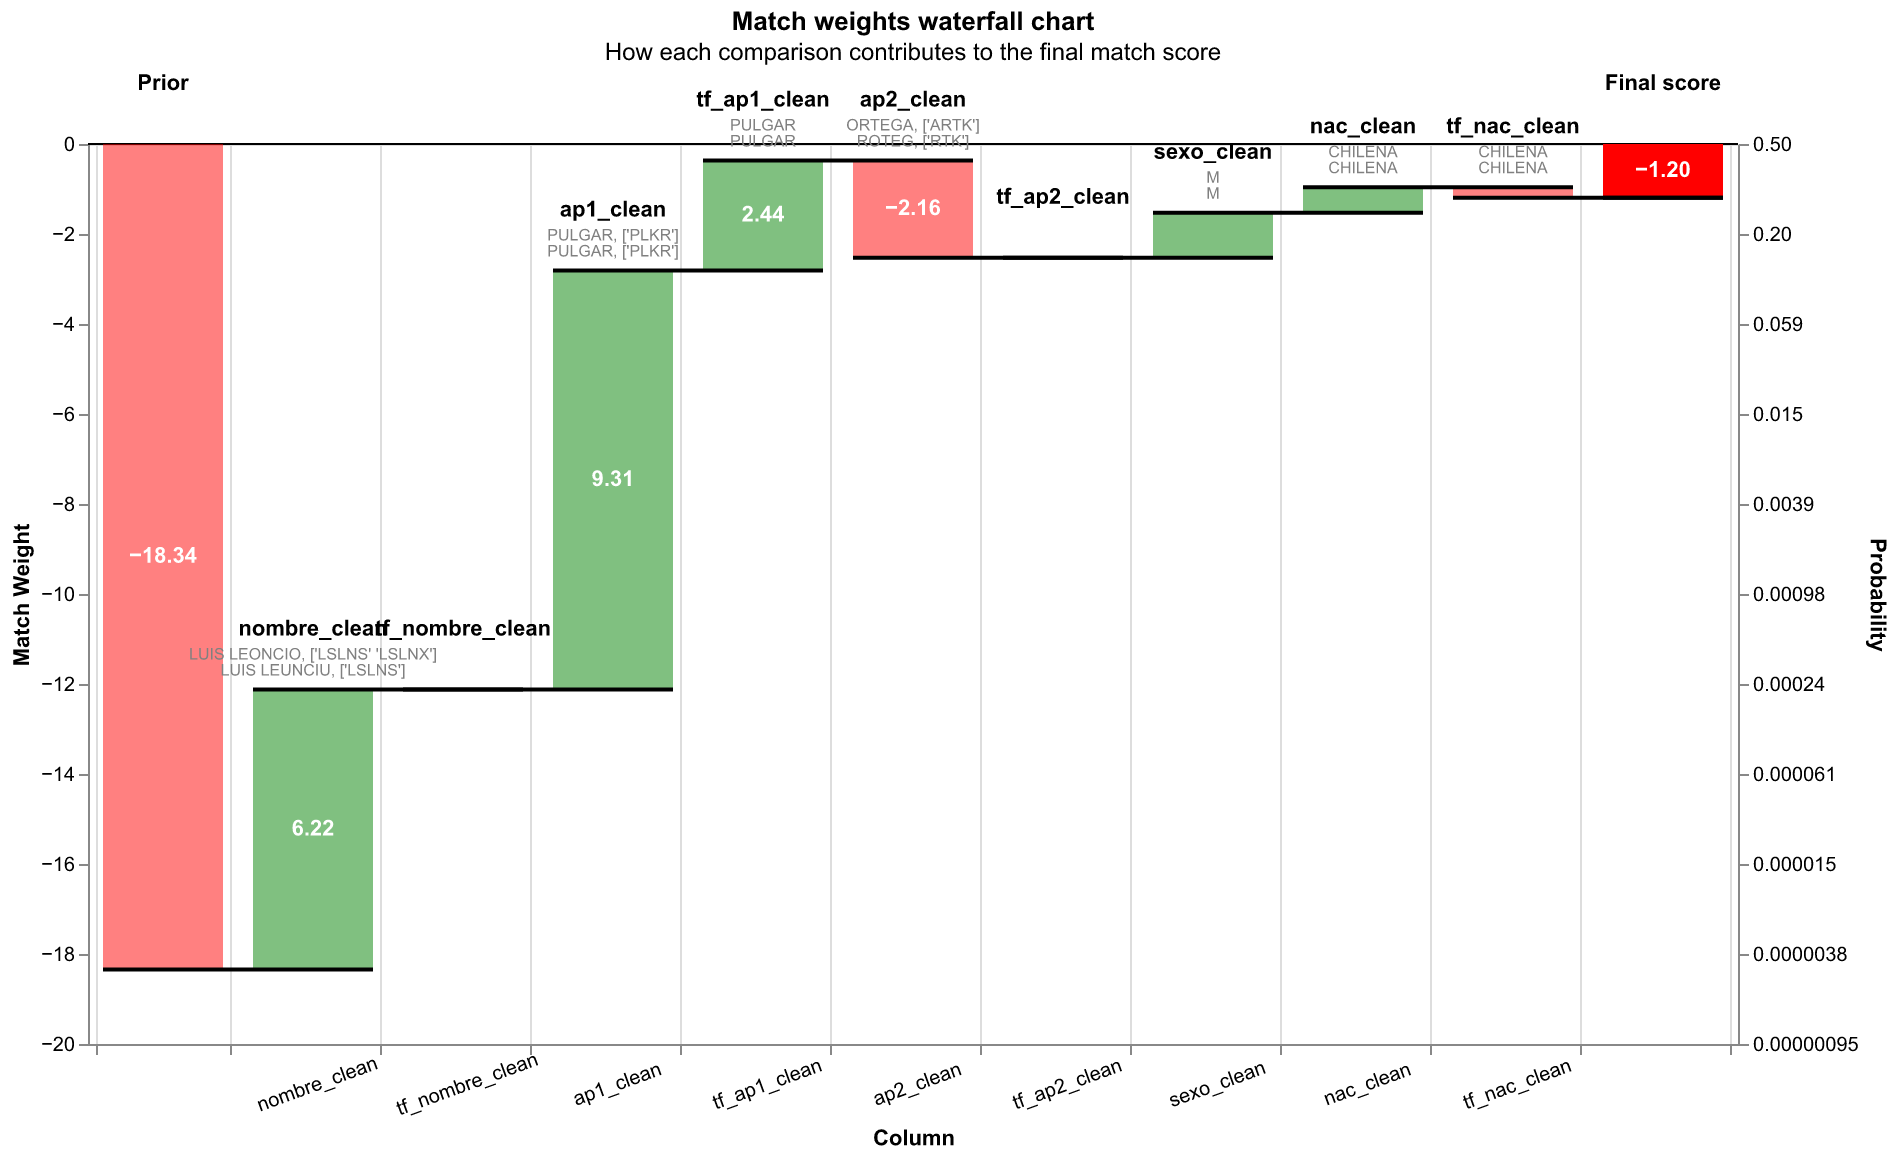

In [6]:
borderline = predictions[
    (predictions["match_probability"] > 0.3) & (predictions["match_probability"] < 0.9)
].sort_values("match_probability")

show(linker.visualisations.waterfall_chart(
    borderline.head(4).to_dict(orient="records"), filter_nulls=False))

**What it is for.** Clerical review, and answering "why did this pair score
that?" — including when the person asking is a data subject or an auditor.

**How to read it.** Each column is one pair. Bars show how each field moved the
score from the prior, and the final bar is where it landed.

This is the chart that makes a linkage explainable. "The model gave 0.62" is not
an explanation; "the surnames agreed strongly, the given name only loosely, and
sex disagreed" is.

```{note}
`waterfall_chart()` requires `retain_intermediate_calculation_columns=True` in
the settings, or it fails with a `ValueError` about missing columns.
```

## 5. Charts for people who do not build models

None of the four charts above belongs in a statistical bulletin. They are
diagnostics for the team that built the linkage.

A general audience needs to know two things, and neither is a match weight.

### How much of the population did we link, and did that vary?

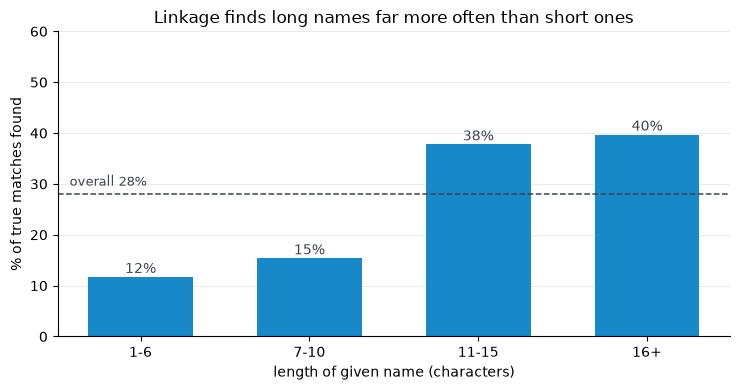

In [7]:
import matplotlib.pyplot as plt

BLUE, MUTED, INK = "#1789c9", "#b9c6d4", "#3d4451"

truth = fonasa_m.merge(
    suseso_m[["unique_id", "true_person_id"]], on="true_person_id", suffixes=("", "_s"))
linked_ids = set(predictions.loc[predictions["match_probability"] >= THRESHOLD, "unique_id_l"])
truth["was_found"] = truth["unique_id"].isin(linked_ids)
truth["name_length"] = truth["nombre_clean"].str.len()

bands = pd.cut(truth["name_length"], [0, 6, 10, 15, 100],
               labels=["1-6", "7-10", "11-15", "16+"])
rates = truth.groupby(bands, observed=False)["was_found"].mean()
overall = truth["was_found"].mean()

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(rates.index.astype(str), rates.values * 100, color=BLUE, width=0.62)
ax.axhline(overall * 100, color=INK, linestyle="--", linewidth=1.1)
ax.text(-0.42, overall * 100 + 1.6, f"overall {overall*100:.0f}%",
        color=INK, fontsize=9, ha="left")

for x, v in enumerate(rates.values * 100):
    ax.text(x, v + 0.8, f"{v:.0f}%", ha="center", fontsize=10, color=INK)

ax.set_ylabel("% of true matches found")
ax.set_xlabel("length of given name (characters)")
ax.set_title("Linkage finds long names far more often than short ones")
ax.set_ylim(0, 60)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e6e6e6", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

One series, so no legend is needed — the title names what is plotted. Every bar
is labelled directly, and the dashed line gives the overall rate as a reference,
so a reader can see both the level and the spread without consulting a table.

This chart is a claim about **fitness for purpose**, and it is the one an
informed reader will want. If your analysis compares groups whose linkage rates
differ this much, that difference is partly an artefact of the linkage and the
publication has to say so.

### How certain are the links we published?

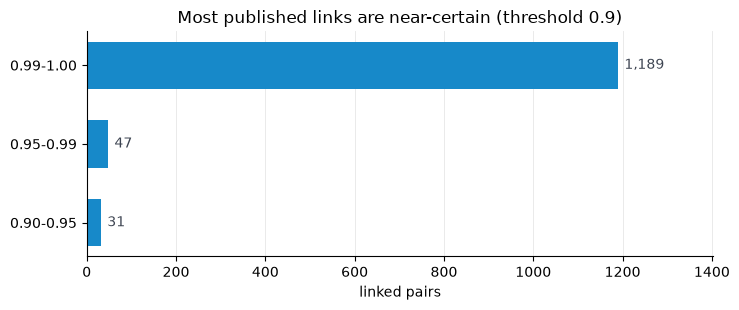

In [8]:
accepted = predictions[predictions["match_probability"] >= THRESHOLD]
conf = pd.cut(accepted["match_probability"], [0.9, 0.95, 0.99, 1.0001],
              labels=["0.90-0.95", "0.95-0.99", "0.99-1.00"])
counts = conf.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(counts.index.astype(str), counts.values, color=BLUE, height=0.6)
for y, v in enumerate(counts.values):
    ax.text(v + 15, y, f"{v:,}", va="center", fontsize=10, color=INK)

ax.set_xlabel("linked pairs")
ax.set_title(f"Most published links are near-certain (threshold {THRESHOLD})")
ax.set_xlim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#e6e6e6", linewidth=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

Publishing the *distribution* of confidence, rather than only a count of links,
lets a reader judge how much of the result rests on marginal decisions. It costs
one chart and it pre-empts the obvious question.

## 6. Interactive dashboards

Splink can export self-contained HTML dashboards. These are working tools rather
than publication outputs: send them to a reviewer, not to a bulletin.

In [9]:
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

linker.visualisations.comparison_viewer_dashboard(
    df_predict, str(OUT / "comparison-viewer.html"), overwrite=True
)

print("written:")
for f in sorted(OUT.glob("*.html")):
    print(f"  {f}  ({f.stat().st_size/1024:.0f} KB)")

written:
  outputs/comparison-viewer.html  (2876 KB)


The **comparison viewer** shows the score distribution, lets a reviewer filter to
any region of it, and displays the field-by-field comparison for individual pairs.
It is the fastest way for someone who did not build the model to develop a feel
for what it is doing — and the fastest way to find a systematic error, because
patterns in the borderline region become obvious when you can page through them.

## 7. What a linkage deliverable contains

Six artefacts. Anything less and someone will have to guess.

In [10]:
pd.DataFrame({
    "artefact": [
        "Linked pairs (crosswalk)",
        "Cluster assignment",
        "Trained model",
        "Preparation and pipeline code",
        "Quality statement",
        "Diagnostic charts",
    ],
    "file": [
        "linked-pairs.csv",
        "clusters.csv",
        "models/linkage-model.json",
        "the notebooks or scripts, version-controlled",
        "quality-statement.md (see chapter 3.1)",
        "match weights, m/u, score distribution",
    ],
    "who needs it": [
        "the analyst joining the data back",
        "anyone counting people rather than pairs",
        "anyone re-running or auditing the linkage",
        "anyone reproducing it",
        "anyone using or citing the output",
        "reviewers and auditors",
    ],
})

,artefact,file,who needs it
0,Linked pairs (crosswalk),linked-pairs.csv,the analyst joining the data back
1,Cluster assignment,clusters.csv,anyone counting people rather than pairs
2,Trained model,models/linkage-model.json,anyone re-running or auditing the linkage
3,Preparation and pipeline code,"the notebooks or scripts, version-controlled",anyone reproducing it
4,Quality statement,quality-statement.md (see chapter 3.1),anyone using or citing the output
5,Diagnostic charts,"match weights, m/u, score distribution",reviewers and auditors


Two things about that list are easy to skip and expensive to skip.

**The trained model is part of the deliverable.** Without it the linkage cannot
be re-run or audited, and given that *u* estimation is unseeded, it cannot even be
reproduced from the same code.

**The crosswalk carries no identifying fields.** It is a mapping between record
identifiers plus a score. Each institution joins it back to its own records using
the internal key from chapter 2.3 — the separation principle carried through to
the output.

[Chapter 3.1](communicating-methods.md) covers the quality statement, and
[chapter 3.3](quality-metric-reference.md) defines every metric it should quote.